# 3D CNN Models — Hand Gesture Recognition

Two models trained directly on raw-pixel video clips from `clip_extraction.ipynb`:
1. **Model A** - a compact 3D CNN (Conv3D stack) trained from scratch
2. **Model B** - pretrained R(2+1)D-18 (Kinetics-400), fine-tuned

Both are evaluated with the shared `src/evaluation/metrics.py` module so results are
directly comparable to the landmark-based branche.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src.data.dataset import GESTURE_NAMES, NUM_CLASSES
from src.evaluation.metrics import full_evaluation, measure_inference_time, compare_models
from src.models.video_dataset import (
    GestureClipDataset, stratified_train_val_split, compute_class_weights,
    IMAGENET_MEAN, IMAGENET_STD, KINETICS_MEAN, KINETICS_STD,
)

CLIP_DIR = "../data/processed"

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: mps


## 1. Dataset & DataLoader

Stratified train/val split carved out of the train metadata only (test stays untouched,
official split). 

Class weights are computed from the train split for the weighted loss.

In [2]:
train_df, val_df = stratified_train_val_split(
    f"{CLIP_DIR}/train/_metadata.csv", val_frac=0.15, seed=42
)
print(f"Train: {len(train_df)}   Val: {len(val_df)}")

class_weights = compute_class_weights(train_df, num_classes=NUM_CLASSES)
print("\nClass weights (balanced: N / (num_classes * count)):")
for name, w in zip(GESTURE_NAMES, class_weights):
    print(f"  {name:14s} {w:.3f}")

Train: 2649   Val: 468

Class weights (balanced: N / (num_classes * count)):
  Point-1f       0.322
  Point-2f       0.323
  Click-1f       1.617
  Click-2f       1.617
  Throw-up       1.617
  Throw-down     1.617
  Throw-left     1.617
  Throw-right    1.617
  Open-twice     1.617
  DblClick-1f    1.630
  DblClick-2f    1.617
  Zoom-in        1.617
  Zoom-out       1.617


In [3]:
BATCH_SIZE = 8

# ImageNet stats for the from-scratch model (Model B will use its own
# Kinetics-normalized loaders).
train_ds = GestureClipDataset(train_df, mean=IMAGENET_MEAN, std=IMAGENET_STD, train=True)
val_ds = GestureClipDataset(val_df, mean=IMAGENET_MEAN, std=IMAGENET_STD, train=False)
test_ds = GestureClipDataset(f"{CLIP_DIR}/test/_metadata.csv", mean=IMAGENET_MEAN, std=IMAGENET_STD, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}   Val batches: {len(val_loader)}   Test batches: {len(test_loader)}")

Train batches: 332   Val batches: 59   Test batches: 138


## 2. Sanity check — inspect a batch

In [4]:
clips, labels = next(iter(train_loader))
print(f"Batch clips shape:  {clips.shape}")   # expect (B, 3, 16, 112, 112)
print(f"Batch labels shape: {labels.shape}")
print(f"dtype: {clips.dtype}, value range: [{clips.min():.3f}, {clips.max():.3f}]")
print(f"Labels: {labels.tolist()}")

Batch clips shape:  torch.Size([8, 3, 16, 112, 112])
Batch labels shape: torch.Size([8])
dtype: torch.float32, value range: [-2.118, 2.640]
Labels: [10, 0, 0, 4, 12, 1, 11, 0]


## 3. Visualize a clip — raw vs. augmented

Confirms the augmentation pipeline (flip / crop jitter / temporal jitter / color jitter)
is doing something reasonable.

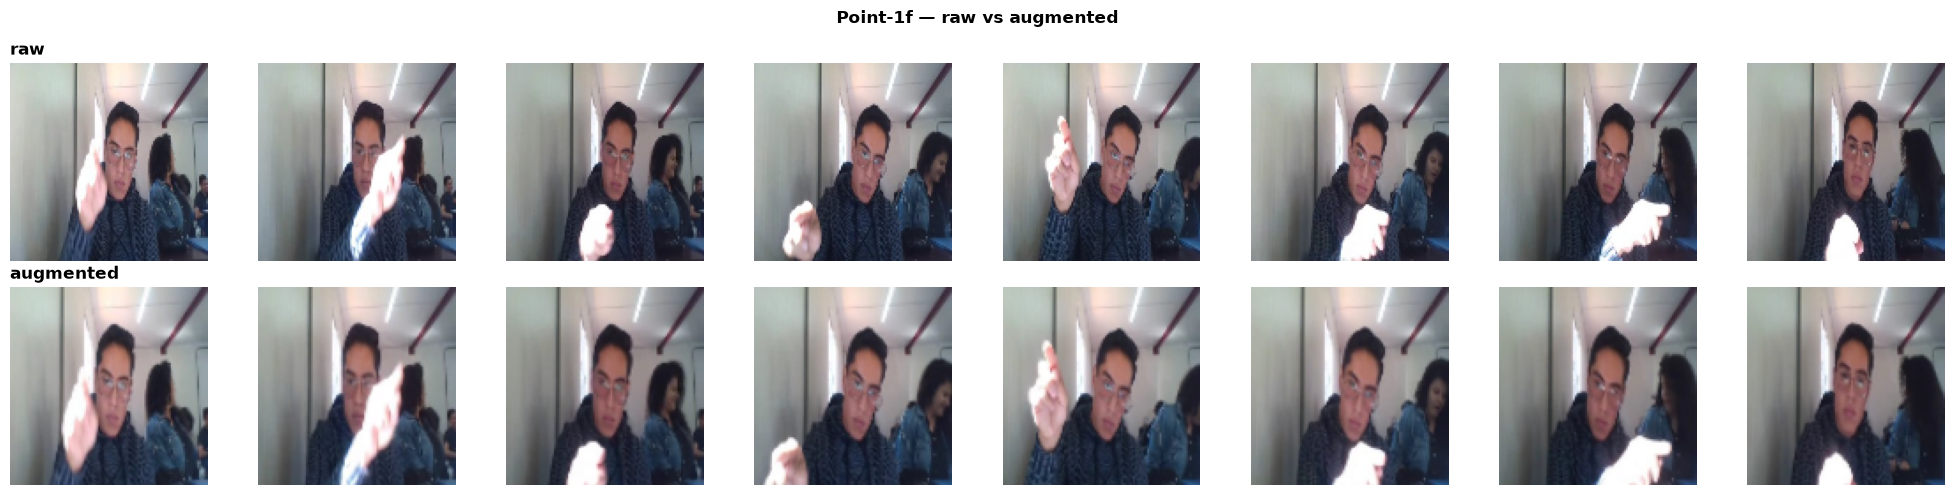

In [5]:
def denormalize(clip_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """(3, T, H, W) normalized tensor -> (T, H, W, 3) uint8 for display."""
    clip = clip_tensor.numpy() * std.reshape(3, 1, 1, 1) + mean.reshape(3, 1, 1, 1)
    clip = np.clip(clip, 0, 1)
    clip = np.transpose(clip, (1, 2, 3, 0))  # (T, H, W, 3)
    return (clip * 255).astype(np.uint8)


idx = 0
raw_clip = np.load(train_df.iloc[idx]['npy_path'])
aug_clip_t, label = train_ds[idx]
aug_clip = denormalize(aug_clip_t)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for i in range(8):
    axes[0, i].imshow(raw_clip[i * 2]); axes[0, i].axis('off')
    axes[1, i].imshow(aug_clip[i * 2]); axes[1, i].axis('off')
axes[0, 0].set_title("raw", loc='left', fontweight='bold')
axes[1, 0].set_title("augmented", loc='left', fontweight='bold')
plt.suptitle(f"{train_df.iloc[idx]['gesture_name']} — raw vs augmented", fontweight='bold')
plt.tight_layout()
plt.show()